In [33]:
#Data handling
import pandas as pd
import numpy as np

#visaulization
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr 
#Import Pearson Correlation function from scipy library Pearson Correlation is used to check the relationship between two numerical variables.


In [2]:
#Load Dataset
df = pd.read_csv("student_performance.csv")

df.head()

,Student_ID,Age,Gender,Study_Hours,Attendance(%),Test_Score,Grade
0,S0524,21,Female,2.7,74.0,37.0,F
1,S0603,19,Male,1.5,93.1,26.0,F
2,S0527,20,Female,6.8,97.2,88.0,A
3,S0032,18,Female,6.2,93.5,55.0,C
4,S0617,21,Male,7.4,99.2,77.0,B


In [3]:
# Check dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Student_ID     1020 non-null   object 
 1   Age            1020 non-null   int64  
 2   Gender         1020 non-null   object 
 3   Study_Hours    989 non-null    float64
 4   Attendance(%)  990 non-null    float64
 5   Test_Score     1020 non-null   float64
 6   Grade          1011 non-null   object 
dtypes: float64(3), int64(1), object(3)
memory usage: 55.9+ KB


In [14]:
# Check missing values
df.isnull().sum()


Student_ID       0
Age              0
Gender           0
Study_Hours      0
Attendance(%)    0
Test_Score       0
Grade            0
dtype: int64

In [5]:
# Check duplicate rows
df.duplicated().sum()

np.int64(20)

In [7]:
# Remove duplicates
df = df.drop_duplicates()


In [8]:
df.duplicated().sum()

np.int64(0)

In [10]:
# Fill missing numerical values with median
df['Attendance(%)'] = df['Attendance(%)'].fillna(df['Attendance(%)'].median())


In [12]:
# Fill missing numerical values with median
df['Study_Hours'] = df['Study_Hours'].fillna(df['Study_Hours'].median())

In [13]:
# Fill missing categorical values with mode
df['Grade'] = df['Grade'].fillna(df['Grade'].mode()[0])

In [18]:
df.columns

Index(['Student_ID', 'Age', 'Gender', 'Study_Hours', 'Attendance(%)',
       'Test_Score', 'Grade'],
      dtype='object')

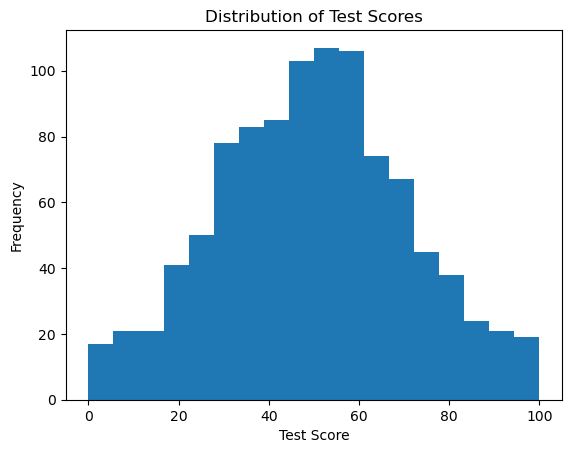

In [17]:
#Shows how exam scores are distributed among students.
plt.hist(df['Test_Score'], bins='auto')
plt.title("Distribution of Test Scores")
plt.xlabel("Test Score")
plt.ylabel("Frequency")
plt.show()

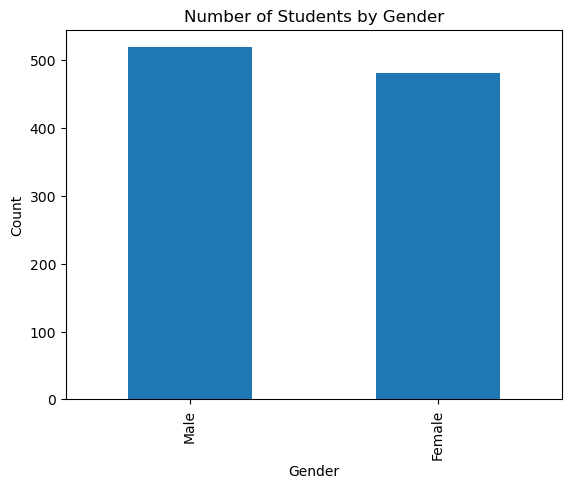

In [19]:
#Compares the number of male and female students.
df['Gender'].value_counts().plot(kind='bar')

plt.title("Number of Students by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

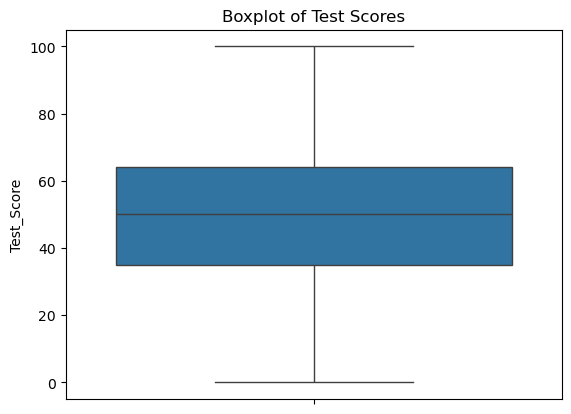

In [24]:
#Identifies outliers and spread of exam scores.
sns.boxplot(y=df['Test_Score'])

plt.title("Boxplot of Test Scores")
plt.show()

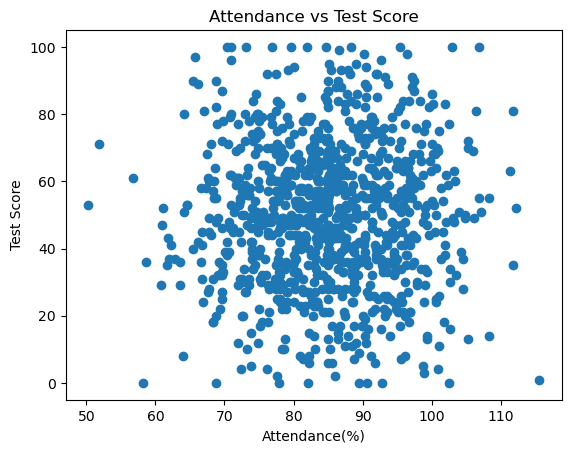

In [25]:
#Shows relationship between attendance and exam performance.
plt.scatter(df['Attendance(%)'], df['Test_Score'])

plt.title("Attendance vs Test Score")
plt.xlabel("Attendance(%)")
plt.ylabel("Test Score")
plt.show()


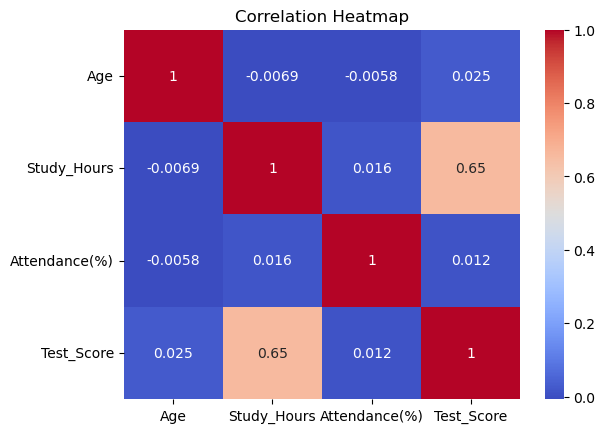

In [26]:
#Shows correlation among numerical variables.
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

In [27]:
#descriptive statistics
df.describe()

,Age,Study_Hours,Attendance(%),Test_Score
count,1000.0000,1000.000000,1000.000000,1000.00000
mean,20.9600,5.159700,84.850400,49.80800
std,2.0036,2.522282,9.820518,21.18745
min,18.0000,-2.000000,50.300000,0.00000
25%,19.0000,3.700000,78.000000,35.00000
50%,21.0000,5.100000,85.000000,50.00000
75%,23.0000,6.300000,91.725000,64.00000
max,24.0000,25.000000,115.600000,100.00000


In [34]:

#Calculate correlation between Study Hours and Test Score
corr, p_value = pearsonr(
    df['Study_Hours'],
    df['Test_Score']
)


# Display correlation coefficient and p-value
print("Correlation Coefficient:", corr)
print("P-value:", p_value)

## Check whether the relationship is statistically significant
if p_value < 0.05:
    print("Reject H0")
    print("There is a significant relationship between Study Hours and Test Score.")
else:
    print("Fail to Reject H0")
    print("There is no significant relationship between Study Hours and Test Score.")


Correlation Coefficient: 0.6546701106112645
P-value: 2.0022420469951192e-123
Reject H0
There is a significant relationship between Study Hours and Test Score.


In [ ]:
# The Pearson correlation coefficient between Study Hours and Test Score is 0.6547, indicating a moderately strong positive relationship.
# This means that students who study more hours tend to achieve higher test scores.

# The p-value (2.00 × 10⁻¹²³) is much smaller than the significance level of 0.05. Therefore, the null hypothesis (H₀) is rejected.

# There is sufficient statistical evidence to conclude that a significant relationship exists between Study Hours and Test Score.

In [ ]:
# The analysis indicates that attendance plays an important role in student academic performance. 
# Students who attend classes more regularly tend to achieve better examination results. 
# Therefore, improving attendance may help improve academic outcomes.